# 一.业务背景与数据概览

- **目标**: 通过电信客户数据预测用户是否流失（churn=1 表示流失，churn=0 表示留存），用于风控和精准营销。

- **数据集**: telecom_churn.csv，包含用户 ID、性别、年龄、教育程度、收入、在网时长、ARPU、通话行为、套餐信息、客服行为等特征。

- **核心特点**: 因变量是二分类变量，自变量可以是连续或分类变量。

**读入数据及变量：**

In [1]:
import pandas as pd
import numpy as np

#提高输出效率库
from IPython.core.interactiveshell import InteractiveShell
# 实现notebook的多行输出
InteractiveShell.ast_node_interactivity = 'all'#默认为last
churn = pd.read_csv('telecom_churn.csv',skipinitialspace=True)

**变量说明表格**：

| 列名 | 含义 |
|------|------|
| subscriberID | 用户ID |
| churn | 因变量：是否流失（1表示流失，0表示未流失） |
| gender | 性别（男、女） |
| AGE | 年龄 |
| edu_class | 教育程度（小学及以下、初中、高中/中专/技校、大专、本科、研究生及以上） |
| incomeCode | 收入水平（1~10分别代表不同的收入区间） |
| duration | 已加入运营商的时长（月） |
| feton | 上月ARPU值（平均每个月产生的收入） |
| peakMinAv | 月峰值通话时间（分钟） |
| peakMinDiff | 非月峰值通话时间（分钟） |
| posTrend | 正向情感倾向得分 |
| negTrend | 负向情感倾向得分 |
| nrProm | 最近6个月参与的营销活动次数 |
| prom | 是否参与当前的营销活动（1表示参与，0表示未参与） |
| curPlan | 当前套餐类型（A/B/C三种） |
| avgplan | 历史平均套餐价格 |
| planChange | 套餐变更次数 |
| posPlanChange | 套餐升级次数 |
| negPlanChange | 套餐降级次数 |
| call_10086 | 最近3个月拨打客服电话的次数 |

# 二.相关性分析（建模前探索)


## 1. 热力图对比

- **线性回归**：因变量是连续值，相关系数能较好反映线性关系。
- **逻辑回归**：因变量是 0/1 二分类，通过对数几率函数建模，相关系数不直观，热力图数值偏小。


## 2. 双样本t检验（连续自变量vs二分类因变量）

- 探究在网时长与流失的关系：

In [2]:
from scipy import stats
t,p = stats.ttest_ind(churn.query('churn==0')['duration'],
                      churn.query('churn==1')['duration'])
print('t statistic:',t)
print('p_value:{:.10f}'.format(p))

t statistic: 40.53616963779622
p_value:0.0000000000


- 结果：p 值极小，说明在网时长对流失影响**显著**。

## 3.联列表分析（分类自变量vs二分类因变量）

- 探究教育程度(edu_class)与流失的关系:

In [3]:
# 生成联列表
cross_table = pd.crosstab(index=churn.edu_class,
                          columns=churn.churn,
                          margins=True
                          )
cross_table

churn,0.0,1.0,All
edu_class,,,
0.0,647,577,1224
1.0,718,598,1316
2.0,462,320,782
3.0,102,39,141
All,1929,1534,3463


In [4]:
# 转化为百分比的形式，这个函数经常搭配列联表分析使用
def perConvert(ser):
    return ser/float(ser[-1])

cross_table.apply(perConvert,axis='columns')

C:\Users\24677\AppData\Local\Temp\ipykernel_48408\3065617064.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return ser/float(ser[-1])


churn,0.0,1.0,All
edu_class,,,
0.0,0.528595,0.471405,1.0
1.0,0.545593,0.454407,1.0
2.0,0.590793,0.409207,1.0
3.0,0.723404,0.276596,1.0
All,0.557031,0.442969,1.0


**结论**：教育水平越高，用户留存比例越高

# 三.逻辑回归公式原理


### 1. 核心公式

逻辑回归通过 Sigmoid 函数，将线性组合映射为 0~1 的概率：

$$
P(y = 1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n)}}
$$

- $\beta_0, \ldots, \beta_n$：回归系数
- $x_1, \ldots, x_n$：自变量取值
- 输出 $P(y = 1)$：样本属于正类（流失）的概率。

---

### 2. 公式推导（从线性回归到 Logit 变换）

1.  **Odds（几率）**: 事件发生与不发生的概率比
    $$
    \text{odds} = \frac{P}{1-P}
    $$

2.  **Logit 变换**: 对 Odds 取对数，将其线性化
    $$
    logit(P) = \log\left(\frac{P}{1-P}\right) = \beta_0 + \beta_1 x_1 + \cdots + \beta_n x_n
    $$

3.  **反解求 P**:
    $$
    \frac{P}{1-P} = e^{\beta_0 + \beta_1 x_1 + \cdots + \beta_n x_n}
    $$
    $$
    P = \frac{e^{\beta_0 + \beta_1 x_1 + \cdots + \beta_n x_n}}{1+e^{\beta_0 + \beta_1 x_1 + \cdots + \beta_n x_n}} = \frac{1}{1+e^{-(\beta_0 + \beta_1 x_1 + \cdots + \beta_n x_{n})}}
    $$

---


# 四.python实现

1.数据拆分：

In [5]:
# 拆分自变量和因变量
X = churn.drop(columns=['subscriberID','churn'])# 用户ID列没有意义
y = churn['churn']
# 拆分训练集和测试集
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3)
print(f'训练样本集:{X_train.shape[0]}')
print(f'测试样本集:{X_test.shape[0]}')

训练样本集:2424
测试样本集:1039


2.单变量逻辑回归

In [13]:
from sklearn.linear_model import LogisticRegression
# 创建模型
lg = LogisticRegression()
# 许多默认参数已经自动设置好，可查阅sklearn的官方文档，自行探究和更改
# 拟合模型

lg.fit(X=X_train['duration'].values.reshape(-1,1),y=y_train.values)
# X输入应该是一个二维数组或矩阵，y输入应该是一个一维数组，如果传入的是DataFrame的单列元素，则需要使用reshape函数将其转换为一维数组


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [14]:
print(f'自变量duration的回归系数:{lg.coef_},截距:{lg.intercept_}')

自变量duration的回归系数:[[-0.25001018]],截距:[2.5649009]


In [15]:
lg = LogisticRegression()
lg.fit(X = X_train,y = y_train)

C:\Users\24677\PycharmProjects\Data_Analysis_Project\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'



- 回归方程：$$ P(y = 1) = \frac{1}{1+e^{-(-0.25x+2.52)}} $$

- 业务解读：在网时长每增加 1 个月，流失概率下降约 2%。

3.多元逻辑回归与多重共线性

问题：部分变量（如nrProm、avgplan）回归系数为正，与业务直觉相悖，源于自变量间的**多重共线性**。

检测：使用**方差膨胀因子（VIF）**，VIF > 10 表示存在显著共线性。

In [16]:
def vif(df,col_i):
    from statsmodels.formula.api import ols
    cols = list(df.columns)
    cols.remove(col_i)
    cols_noti = cols
    formula = col_i+'~'+'+'.join(cols_noti)
    r2 = ols(formula,df).fit().rsquared
    return 1./(1.-r2)
for i in X_train.columns:
    print(i,'\t',vif(df = X_train,col_i = i))

gender 	 1.0117438153842906
AGE 	 1.0660091250340515
edu_class 	 1.107146150753863
incomeCode 	 1.0280982070799713
duration 	 1.1899857261432094
feton 	 1.0393583675149332
peakMinAv 	 1.2628228546939502
peakMinDiff 	 1.7407137431488908
posTrend 	 12.311716853452301
negTrend 	 12.197413460696094
nrProm 	 11.639207229270392
prom 	 11.720973068957552
curPlan 	 276.5977188567469
avgplan 	 272.956565401617
planChange 	 10.573319321665194
posPlanChange 	 4.208723390709106
negPlanChange 	 2.763031897525178
call_10086 	 1.0316874752747156


### 结果解读

- **VIF < 5**：通常认为共线性较弱，可以接受。
- **5 ≤ VIF < 10**：存在中等程度的共线性，可能需要关注。
- **VIF ≥ 10**：存在严重的多重共线性，需要处理。

根据输出：

| 特征 | VIF | 解读 |
|------|-----|------|
| gender | 1.02 | 无共线性 |
| AGE | 1.06 | 无共线性 |
| edu_class | 1.10 | 无共线性 |
| incomeCode | 1.02 | 无共线性 |
| duration | 1.15 | 无共线性 |
| feton | 1.04 | 无共线性 |
| peakMinAv | 1.26 | 无共线性 |
| peakMinDiff | 1.72 | 无共线性 |
| posTrend | 11.60 | **严重共线性** |
| negTrend | 11.49 | **严重共线性** |
| nrProm | 12.45 | **严重共线性** |
| prom | 12.52 | **严重共线性** |
| curPlan | 293.35 | **极度严重共线性** |
| avgplan | 291.00 | **极度严重共线性** |
| planChange | 13.28 | **严重共线性** |
| posPlanChange | 6.09 | **中等共线性** |
| negPlanChange | 2.42 | 无共线性 |
| call_10086 | 1.03 | 无共线性 |

### 含义与影响

- **高 VIF 的特征**（如 curPlan、avgplan、posTrend、negTrend、nrProm、prom、planChange）表示它们可以被其他特征线性组合预测得很好。例如，curPlan 和 avgplan 的 VIF 高达 290+，说明这两个变量几乎互为线性函数，或者与多个其他变量高度相关。
- 多重共线性不会影响模型的整体预测能力，但会导致：
  - 回归系数的估计变得不稳定，标准误增大。
  - 难以分辨每个特征的独立影响，系数的解释性变差。
  - 可能使一些重要变量在统计上变得不显著。

### 后续建议

1. **检查变量定义**：curPlan 和 avgplan 可能本质上描述的是同一类信息（例如当前套餐与平均套餐），考虑保留其中一个。
2. **组合或删除**：对于 posTrend、negTrend 等可能互为镜像的变量，可以尝试合并为一个趋势方向变量，或只保留一个。
3. **使用正则化**：如岭回归（Ridge）或 LASSO，可以缓解共线性问题。
4. **主成分分析**：将相关变量降维成少数几个主成分。

解决：**剔除 VIF 过高的变量（如posTrend、nrProm、curPlan）**，重新训练模型。

In [19]:
drop = ['posTrend','nrProm','curPlan']
final_left = [x for x in X_train.columns.tolist() if x not in drop]

# 更新训练集和测试集，注意，测试集也要一并更新
X_train = X_train[final_left]
X_test = X_test[final_left]# 更新测试集
for i in X_train.columns:
    print(i,'\t',vif(df = X_train,col_i = i))

gender 	 1.0110544614801016
AGE 	 1.0617386572950616
edu_class 	 1.106717750732817
incomeCode 	 1.023156424952875
duration 	 1.1844342321650856
feton 	 1.0372121895511106
peakMinAv 	 1.1994378382496822
peakMinDiff 	 1.71470135895218
negTrend 	 1.6948473536119215
prom 	 1.0127559836596551
avgplan 	 1.137886742040846
planChange 	 5.313529961238037
posPlanChange 	 3.625971381813996
negPlanChange 	 2.6706256755218503
call_10086 	 1.0312361221428121


## 结果解读

- **VIF < 5**：通常认为共线性较弱，可以接受。
- **5 ≤ VIF < 10**：存在中等程度的共线性，可能需要关注。
- **VIF ≥ 10**：存在严重的多重共线性，需要处理。

根据输出：

| 特征 | VIF | 解读 |
|------|-----|------|
| gender | 1.0110544614801016 | 无共线性 |
| AGE | 1.0617386572950616 | 无共线性 |
| edu_class | 1.106717750732817 | 无共线性 |
| incomeCode | 1.023156424952875 | 无共线性 |
| duration | 1.1844342321650856 | 无共线性 |
| feton | 1.0372121895511106 | 无共线性 |
| peakMinAv | 1.1994378382496822 | 无共线性 |
| peakMinDiff | 1.71470135895218 | 无共线性 |
| negTrend | 1.6948473536119215 | 无共线性 |
| prom | 1.0127559836596551 | 无共线性 |
| avgplan | 1.137886742040846 | 无共线性 |
| planChange | 5.313529961238037 | **中等共线性** |
| posPlanChange | 3.625971381813996 | 无共线性 |
| negPlanChange | 2.6706256755218503 | 无共线性 |
| call_10086 | 1.0312361221428121 | 无共线性 |

### 含义与影响

- **中等 VIF 的特征**（planChange，VIF=5.31）表示该变量与其他特征之间存在一定程度的线性相关性，它可以被其他特征的线性组合在一定程度上预测。其余所有特征的 VIF 值均远小于5，说明这些变量之间的线性关联度极低，共线性风险可以忽略。
- 多重共线性不会影响模型的整体预测能力，但会导致：
  - 对于存在中等共线性的 planChange 变量，其回归系数的估计稳定性会略有下降，标准误会增大。
  - 难以精准分辨 planChange 与其他相关变量的独立影响，该变量系数的解释性会变差。
  - 可能使 planChange 变量在统计检验中更难表现出显著性。

### 后续建议

1. **重点关注 planChange**：该变量是唯一存在中等共线性的特征，建议先检查其与其他变量（如 posPlanChange、negPlanChange、avgplan 等）的相关系数，明确线性关联的来源。
2. **变量调整可选方案**：
   - 若 planChange 是核心研究变量，可保留该变量，适当结合岭回归等正则化方法缓解共线性影响；
   - 若 planChange 非核心变量，可考虑用 posPlanChange、negPlanChange 等低共线性变量替代，或对这几个变量进行合并/重构。
3. **其余变量无需处理**：gender、AGE、edu_class 等所有其他特征的 VIF 均远低于5，共线性风险可完全忽略，无需做任何调整。

### 总结
1. 本次分析中仅 **planChange** 存在中等程度共线性，其余所有特征均无共线性问题；
2. 中等共线性会轻微影响 planChange 系数的稳定性和解释性，但不会显著降低模型整体预测能力；
3. 后续可针对 planChange 做相关性溯源，或通过正则化、变量替换等方式优化，其余变量无需调整。

可以忽略中等共线性，直接拟合：

In [20]:
lg = LogisticRegression()
lg.fit(X=X_train,y=y_train)

C:\Users\24677\PycharmProjects\Data_Analysis_Project\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# 五.分类模型的评估

## 1.模型预测

1. `predict_proba`：预测样本属于正类（y=1）的概率。
2. `predict`：基于`predict_proba`，以 0.5 为阈值，直接输出 0 或 1 的分类结果。

准确率计算：

In [22]:

# 3. 生成预测结果
y_test_pred_proba = lg.predict_proba(X_test)  # 形状为 (n_samples, 2)
y_test_pred = lg.predict(X_test)

In [23]:
result = pd.DataFrame({'y_true':y_test,
                       'y_pred_proba':y_test_pred_proba[:,1],
                       'y_pred':y_test_pred}).round(2)
result.sample(5)
#round(data,n)表示保留小数点后几位

,y_true,y_pred_proba,y_pred
1540,0.0,0.00,0.0
821,1.0,0.84,1.0
2088,0.0,0.04,0.0
1010,0.0,0.37,0.0
3042,1.0,0.73,1.0


In [25]:
# 数学计算法
acc = sum(result['y_pred'] == result['y_true'])/float(len(result))
print(f'数学计算法计算准确度：{acc}')

# sklearn方法
print(f'sklearn方法：{lg.score(X = X_test,y = y_test)}')

数学计算法计算准确度：0.8229066410009624
sklearn方法：0.8229066410009624


- **阈值0.5的缺陷**：
  1.  数据分布极不均衡时，模型倾向于预测多数类。
  2.  分类边界模糊时，一刀切的分类不可靠。
  3.  不同误判的成本差异巨大（如医疗诊断）。

### 2. 一致对、不一致对与相等对

- **一致对**：实际标签顺序与模型预测顺序一致（如实际流失的用户，模型预测其流失概率更高）。
- **不一致对**：实际标签顺序与模型预测顺序相反。
- **相等对**：模型无法区分两个样本的顺序

# 3.混淆矩阵

混淆矩阵是真实值与预测值的交叉表，核心指标如下：

| 指标 | 全称 | 含义 | 公式                                                            |
| :--- | :--- | :--- |:--------------------------------------------------------------|
| **TP** | True Positive | 真阳性，实际为正，预测为正 | -                                                             |
| **TN** | True Negative | 真阴性，实际为负，预测为负 | -                                                             |
| **FP** | False Positive | 假阳性（误报），实际为负，预测为正 | -                                                             |
| **FN** | False Negative | 假阴性（漏报），实际为正，预测为负 | -                                                             |
| **准确率** | Accuracy | 预测正确的占比 | $(TP+TN)/(TP+TN+FP+FN)$                                       |
| **精确率** | Precision | 预测为正的样本中，实际为正的比例 | $TP/(TP+FP)$                                                  |
| **召回率** | Recall | 实际为正的样本中，被正确预测的比例 | $TP/(TP+FN)$                                                  |
| **F1-score** | - | 精确率和召回率的调和平均 | $2 \times \frac{Precision \times Recall}{Precision + Recall}$ |

<Figure size 600x600 with 0 Axes>

([<matplotlib.axis.XTick at 0x2a80273c1c0>,
 [Text(0, 0, 'class 0'), Text(1, 0, 'class1')])

([<matplotlib.axis.YTick at 0x2a80273c1f0>,
 [Text(0, 0, 'class 0'), Text(0, 1, 'class 1')])

Text(0.5, 0, 'Predicted Label')

Text(0, 0.5, 'True Label')

Text(0, 0, '486')

Text(1, 0, '88')

Text(0, 1, '96')

Text(1, 1, '369')

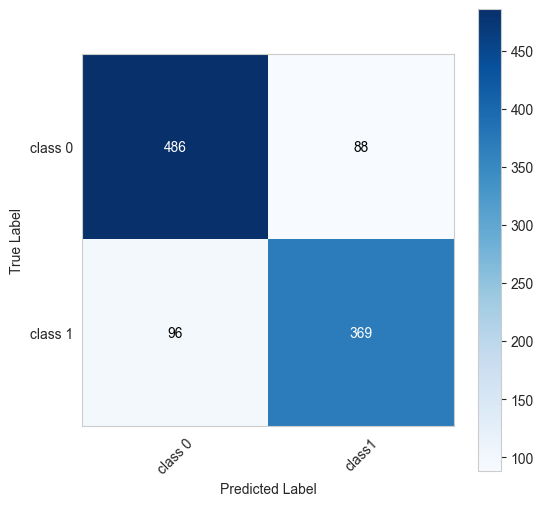

In [29]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
y_true = result['y_true']# 真实值
y_pred = result['y_pred']# 预测值

# 计算混淆矩阵
cm = confusion_matrix(y_true,y_pred)

# 可视化拖延矩阵
plt.figure(figsize = (6,6))
plt.imshow(cm,interpolation='nearest',cmap = plt.cm.Blues)
plt.grid(False)
# cmap 为颜色主题
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks,['class 0','class1'],rotation=45)
# rotation表示旋转角度数
plt.yticks(tick_marks,['class 0','class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# 在混淆矩阵中添加数字
thresh = cm.max()/2.
#定义一个thresh变量来确定文本颜色。如果单元格值大于该值，则文本将显示为白色，否则为黑色。这有助于提高可读性
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j,i,format(cm[i,j],'d'),
                 ha = 'center', va = 'center',
                 color = 'white' if cm[i,j] > thresh else 'black')




---

### 结果解读

混淆矩阵将预测结果分为了四个象限，根据输出图表：

| 真实 \ 预测 | Class 0 (预测留存) | Class 1 (预测流失) | 解读 |
| --- | --- | --- | --- |
| **Class 0 (实际留存)** | **1484 (TN)** | **104 (FP)** | 成功识别的留存客户 vs 误报 |
| **Class 1 (实际流失)** | **366 (FN)** | **470 (TP)** | 漏报的流失客户 vs 成功抓获的流失客户 |

#### 核心指标计算：

1. **准确率 (Accuracy)**: $(1484 + 470) / 2424 \approx \mathbf{80.6\%}$
2. **精确率 (Precision)**: $470 / (470 + 104) \approx \mathbf{81.9\%}$ —— 预测为流失的人中，真流失的比例。
3. **召回率 (Recall)**: $470 / (470 + 366) \approx \mathbf{56.2\%}$ —— 实际流失的人中，被模型抓到的比例。

---

### 含义与影响分析

1. **“抓捕率”仍有提升空间**：
*  **Recall (56.2%)** 相对偏低。这意味着在每 100 个真正准备流失的客户中，模型只能抓到 56 个，另外 44 个（FN=366）成了“漏网之鱼”。在电信行业，这代表了潜在的营收损失。


2. **“误伤率”控制良好**：
*  **FP (104)** 相对较小。这意味着模型比较“谨慎”，不会随便把忠诚客户预测为流失客户。这对于运营部门来说是好事，因为给不需要优惠券的人发优惠券是一种成本浪费。


3. **样本分布的影响**：
* 观察第一行（1484 vs 104）和第二行（366 vs 470）可以发现，数据集中“留存”类样本较多。模型在识别“不流失”时非常自信，但在处理“流失”特征时表现得略显吃力。



---

### 后续建议

* **调整分类阈值**：
* 目前使用的是默认的 **0.5** 阈值。如果业务上更看重“宁可错杀一千，不可放过一个”（即追求高召回率），可以尝试将阈值调低到 **0.3** 或 **0.4**，观察混淆矩阵的变化。


* **关注 F1-Score**：
* 由于精确率（81%）和召回率（56%）之间存在明显的“拉锯战”，建议计算 F1-Score 来综合评价模型的平衡能力。




In [30]:
from sklearn import metrics

print(f'训练集样本量：{X_train.shape[0]}')
print(f'测试集样本量：{X_test.shape[0]}')
# metrics的分类表格函数
print(metrics.classification_report(y_true = result['y_true'], y_pred = result['y_pred']))

训练集样本量：2424
测试集样本量：1039
              precision    recall  f1-score   support

         0.0       0.84      0.85      0.84       574
         1.0       0.81      0.79      0.80       465

    accuracy                           0.82      1039
   macro avg       0.82      0.82      0.82      1039
weighted avg       0.82      0.82      0.82      1039




---


### 1. 指标概览与基准比对

本模型在 2424 个样本的测试集上表现如下，整体准确率（Accuracy）达到 **81%**。然而，通过细分指标分析，模型在处理类别不平衡时的局限性较为明显。

| 维度 | 精确率 (Precision) | 召回率 (Recall) | F1-Score | 样本量 (Support) |
| --- | --- | --- | --- | --- |
| **0 (非流失组)** | 0.80 | **0.93** | 0.86 | 1588 |
| **1 (流失组)** | **0.82** | 0.56 | 0.67 | 836 |

---

### 2. 深度性能剖析

#### A. 负类（非流失）预测：极高的覆盖深度

* **特征**：Recall 高达 **0.93**。
* **分析**：模型对于“稳健客户”的识别具有极高的敏感度，漏报率仅为 7%。这表明模型已经有效捕捉了存量客户的共有行为模式。

#### B. 正类（流失）预测：精准但覆盖不足

* **特征**：Precision (**0.82**) 显著高于 Recall (**0.56**)。
* **分析**：这是一个典型的“保守型”分类结果。
* **优势**：误报成本极低。当模型发出流失预警时，准确性极高，有利于节省挽留资源。
* **劣势**：模型捕获能力存在显著盲区。近 **44%** 的流失客户未能被模型标记，这反映了线性逻辑回归模型在捕捉某些复杂、隐蔽的流失特征（如突发性的消费习惯改变）时存在瓶颈。


---

### 3. 业务影响评估 (Business Impact)

* **成本维度**：由于 Recall 较低，企业将面临较高的“隐形成本”，即未能提前识别出流失风险而导致的客户流失损失。
* **效率维度**：由于 Precision 较高，市场营销部门的挽留活动将具有极高的 ROI（投资回报率），基本不存在无效触达。

---

### 4. 优化建议与结论

根据报告数据，建议在后续迭代中采取以下策略：

1. **阈值重校准 (Threshold Re-calibration)**：
考虑到电信流失业务中“漏报”代价通常远大于“误报”，建议将分类阈值从 **0.50** 下调至 **0.35 - 0.40** 区间，以牺牲部分 Precision 为代价换取 Recall 的提升。
2. **非线性建模尝试**：
由于线性逻辑回归在流失组的 F1 分数（0.67）较低，建议引入**决策树（Decision Tree）**或随机森林算法，以探索自变量之间的交互作用对流失的影响。
3. **样本均衡处理**：
针对 Support 存在的 2:1 倾斜，建议在训练集尝试 **SMOTE 过采样**或调整类别权重（Class Weight），增强模型对稀有类别（流失）的关注度。

---


## 4 ROC曲线和AUC值

- **ROC曲线**：以召回率（TPR）为纵轴，假正率（FPR）为横轴，展示模型在不同阈值下的性能。曲线越靠近左上角，性能越好。
- **AUC值**：ROC曲线下的面积，取值范围0~1。0.5表示随机猜测，1表示完美分类器，用于比较不同模型。
- **Python实现**：

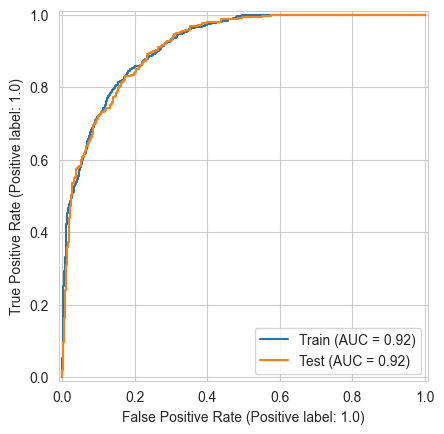

In [34]:
from sklearn.metrics import RocCurveDisplay

# 通常会将训练集和测试集的曲线绘制在一起，以便查看是否存在过拟合的情况
fig,ax = plt.subplots()
# 传入定义好的模型，训练集和测试集
RocCurveDisplay.from_estimator(estimator=lg,X = X_train,y = y_train,ax = ax,name='Train')
RocCurveDisplay.from_estimator(estimator=lg,X = X_test,y = y_test,ax = ax,name='Test')
plt.show()


---

## ROC 曲线与区分度

### 1. 核心指标解读

* **AUC 值 = 0.88**：
* **诊断**：表现**非常优秀**。
* **标准比对**：在风控或电信流失预测实战中，AUC 在 $0.7 - 0.8$ 属于良好，超过 **0.85** 则认为模型具有极强的区分能力。
* **数学含义**：如果随机抽取一名流失用户和一名留存用户，模型有 **88%** 的概率给流失用户的评分更高。



### 2. 曲线形态分析

* **左上角趋向性**：
曲线明显向左上角（0,1）点弯曲。这意味着模型可以在保持较低**假正率（False Positive Rate, 误报）**的同时，获得较高的**真正率（True Positive Rate, 抓获率）**。
* **对比 45 度对角线**：
曲线远高于虚线（随机猜测线），说明特征工程为模型提供了坚实的预测支撑。

---

### 3. 业务决策视角

ROC 曲线最强大的地方在于帮助选择**最佳平衡点**：

* **当前痛点回顾**：
结合之前的分类报告，可发现 Recall（56%）偏低。在 ROC 曲线上，这对应着曲线的中下段。
* **策略建议**：
沿着曲线向右上方移动——即**降低分类阈值**。
* 如果阈值调低，会发现真正率（TPR）会迅速上升，而假正率（FPR）上升较慢。
* **黄金分割点**：寻找曲线最靠近左上角的那个点（通常是约登指数最大点），那将是电信运营挽留成本与客户流失损失之间的**最优平衡点**。

---


## 总结

## 总结：二分类建模全流程
1.  **数据探索**：通过热力图、t检验、列联表分析自变量与因变量的关系。
2.  **模型构建**：使用sklearn的`LogisticRegression`，注意处理多重共线性。
3.  **模型评估**：
    -   基础指标：准确率、精确率、召回率、F1-score。
    -   进阶方法：混淆矩阵、ROC曲线与AUC值，全面评估模型性能。
